<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/316_conjugate_families_1.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>


(distr-coniugate-1-notebook)=
# Distribuzioni coniugate

In questo capitolo, ci focalizziamo sulla derivazione della distribuzione a posteriori attraverso l'uso di una distribuzione a priori coniugata. Sarà esaminato in dettaglio il modello beta-binomiale, un esempio paradigmatico che evidenzia il vantaggio dell'uso delle distribuzioni a priori coniugate in inferenza bayesiana. L'impiego di tali distribuzioni facilita notevolmente il processo di inferenza, permettendo di ottenere una distribuzione a posteriori attraverso calcoli analitici diretti e semplificati. Questa metodologia non solo rende il processo di inferenza più gestibile ma anche più intuitivo, offrendo una chiara dimostrazione di come le scelte a priori influenzino l'analisi bayesiana.

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import arviz as az
from scipy import stats
from scipy.integrate import trapz

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Derivazione analitica della distribuzione a posteriori

Le distribuzioni a priori coniugate costituiscono una classe speciale di distribuzioni di probabilità aventi una particolare caratteristica: se la distribuzione a priori appartiene a questa classe, anche la distribuzione a posteriori appartiene alla stessa classe, ovvero mantiene la stessa forma funzionale. Questo aspetto semplifica notevolmente l'aggiornamento delle nostre credenze riguardo al parametro di interesse, in quanto coinvolge semplicemente la modifica dei parametri della distribuzione a priori. Ad esempio, quando selezioniamo una distribuzione a priori Beta e la verosimiglianza corrisponde a una distribuzione binomiale, la distribuzione a posteriori sarà anch'essa una distribuzione Beta.

Nonostante le distribuzioni a priori coniugate siano la scelta preferibile dal punto di vista matematico, in quanto permettono di calcolare analiticamente la distribuzione a posteriori evitando calcoli complessi, le moderne tecniche di inferenza bayesiana offrono flessibilità nell'utilizzo di una vasta gamma di distribuzioni a priori. Questa flessibilità elimina la necessità di vincolarsi esclusivamente alle distribuzioni coniugate. Tuttavia, le distribuzioni a priori coniugate continuano a giocare un ruolo didattico rilevante, poiché presentano una soluzione analitica per il processo di aggiornamento bayesiano. Nel presene capitolo, esploreremo dettagliatamente il modello beta-binomiale, in cui la verosimiglianza binomiale si combina con la scelta di una distribuzione a priori Beta. Questo modello rappresenta la base dell'inferenza bayesiana su una proporzione.

## Lo schema beta-binomiale 

La distribuzione Beta è una funzione di probabilità che trova applicazione nella descrizione della variabilità di una variabile casuale limitata all'intervallo [0,1]:

$$
\text{Beta}(\theta \mid \alpha, \beta) = \frac{1}{B(\alpha, \beta)}\theta^{\alpha-1} (1-\theta)^{\beta-1} \quad \text{per } \theta \in (0, 1)\,,
$$

dove $B(\alpha, \beta)$ è la funzione beta di Eulero. I suoi parametri, indicati come $\alpha$ e $\beta$, determinano la sua forma (si veda il capitolo {ref}`cont-rv-distr-notebook`). Questa distribuzione è particolarmente indicata per rappresentare le nostre convinzioni iniziali riguardo a una proporzione. 

Una volta raccolti i dati e ottenuto un valore osservato per la proporzione, possiamo sfruttare l'approccio bayesiano per ottenere la distribuzione a posteriori. Questo processo comporta la combinazione della distribuzione a priori con la verosimiglianza, consentendoci di raffinare le nostre credenze sulla proporzione. 

Se optiamo per la distribuzione Beta come distribuzione a priori, la sua forma risulta dunque essere:

$$
\theta^{\alpha - 1} (1 - \theta)^{\beta - 1}.
$$

In questo contesto, la normalizzazione non è rilevante poiché verrà applicata successivamente durante l'aggiornamento bayesiano.

Nel caso di una proporzione, la funzione di verosimiglianza è determinata dalla distribuzione binomiale:

$$
\theta^{y} (1 - \theta)^{n - y}.
$$

Anche in questo caso, il fattore di normalizzazione può essere tralasciato.

Per calcolare la distribuzione a posteriori, è necessario moltiplicare la funzione nucleo a priori, derivante dalla distribuzione Beta, con la funzione nucleo della verosimiglianza binomiale:

$$
\theta^{\alpha - 1} (1 - \theta)^{\beta - 1} \cdot \theta^{y} (1 - \theta)^{n - y} = \theta^{\alpha - 1 + y} (1 - \theta)^{\beta - 1 + n - y}.
$$

Il risultato ottenuto rappresenta la forma non normalizzata della distribuzione Beta con parametri $\alpha+y$ e $\beta+n-y$. 

Il passo successivo è normalizzare questa distribuzione per assicurare che l'integrale su tutto il suo dominio sia uguale a 1. Questo processo coinvolge il calcolo di un nuovo denominatore, che è la costante di normalizzazione per la distribuzione a posteriori.

La distribuzione Beta a posteriori, dopo aver osservato $y$ successi in $n$ prove, ha la forma:

$$
\theta^{\alpha' - 1} (1 - \theta)^{\beta' - 1}
$$

dove $\alpha' = \alpha + y$ e $\beta' = \beta + n - y$. La forma funzionale di questa espressione corrisponde alla di una distribuzione Beta non normalizzata, e per normalizzarla, dobbiamo dividere per la funzione Beta corrispondente ai nuovi parametri $\alpha'$ e $\beta'$.

Il denominatore della distribuzione Beta a posteriori, quindi, è dato da $B(\alpha', \beta')$, che può essere calcolato usando la funzione Gamma come segue:

$$
B(\alpha', \beta') = \frac{\Gamma(\alpha') \Gamma(\beta')}{\Gamma(\alpha' + \beta')}.
$$

Sostituendo $\alpha'$ e $\beta'$ con i loro valori, otteniamo:

$$
B(\alpha + y, \beta + n - y) = \frac{\Gamma(\alpha + y) \Gamma(\beta + n - y)}{\Gamma(\alpha + \beta + n)}.
$$

Questo denominatore assicura che la distribuzione a posteriori sia una distribuzione di probabilità valida normalizzata, cioè che l'area sotto la curva della funzione di densità di probabilità (PDF) sia esattamente uguale a 1 sull'intervallo $[0, 1]$.

In conclusione, quando osserviamo $y$ successi su $n$ prove di Bernoulli e selezioniamo una distribuzione a priori Beta con parametri $\alpha$ e $\beta$, l'aggiornamento bayesiano genera una distribuzione a posteriori Beta con parametri $\alpha+y$ e $\beta+n-y$.

L'esempio appena illustrato rappresenta un caso di analisi coniugata. In particolare, la combinazione della funzione di verosimiglianza binomiale con la distribuzione a priori Beta è noto come "caso coniugato beta-binomiale" ed è regolato dal seguente teorema.

```{admonition} Teorema
Supponiamo di avere una funzione di verosimiglianza $Bin(n, y \mid \theta)$ e una distribuzione a priori $Beta(\alpha, \beta)$. In questo caso, la distribuzione a posteriori del parametro $\theta$ sarà una distribuzione $Beta(\alpha + y, \beta + n - y)$. 
```

## Esempio 

In un esempio ispirato da {cite:t}`McElreath_rethinking` nel suo libro "Statistical Rethinking", consideriamo un esperimento dove otteniamo 6 successi (indicati come "acqua") su un totale di 9 prove (immaginate come lanci di un mappamondo). La verosimiglianza binomiale per questo esperimento è data da:

$$
\theta^y (1-\theta)^{n-y},
$$

dove $y = 6$ è il numero di successi e $n = 9$ è il numero totale di prove.

Se scegliamo una distribuzione a priori Beta con parametri $\alpha = 2$ e $\beta = 2$, possiamo utilizzare l'aggiornamento bayesiano per calcolare i parametri della distribuzione a posteriori, dato l'esito delle nostre prove. L'applicazione del teorema bayesiano porta a una distribuzione a posteriori Beta con i parametri aggiornati $\alpha' = \alpha + y = 8$ e $\beta' = \beta + n - y = 5$.

Ora, vediamo come visualizzare le tre distribuzioni di interesse: la distribuzione a priori Beta($2, 2$), la verosimiglianza binomiale per $y=6$ e $n=9$, e la distribuzione a posteriori Beta($8, 5$). 

/var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/ipykernel_62073/1498819133.py:14: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  likelihood_integral = trapz(likelihood, theta)


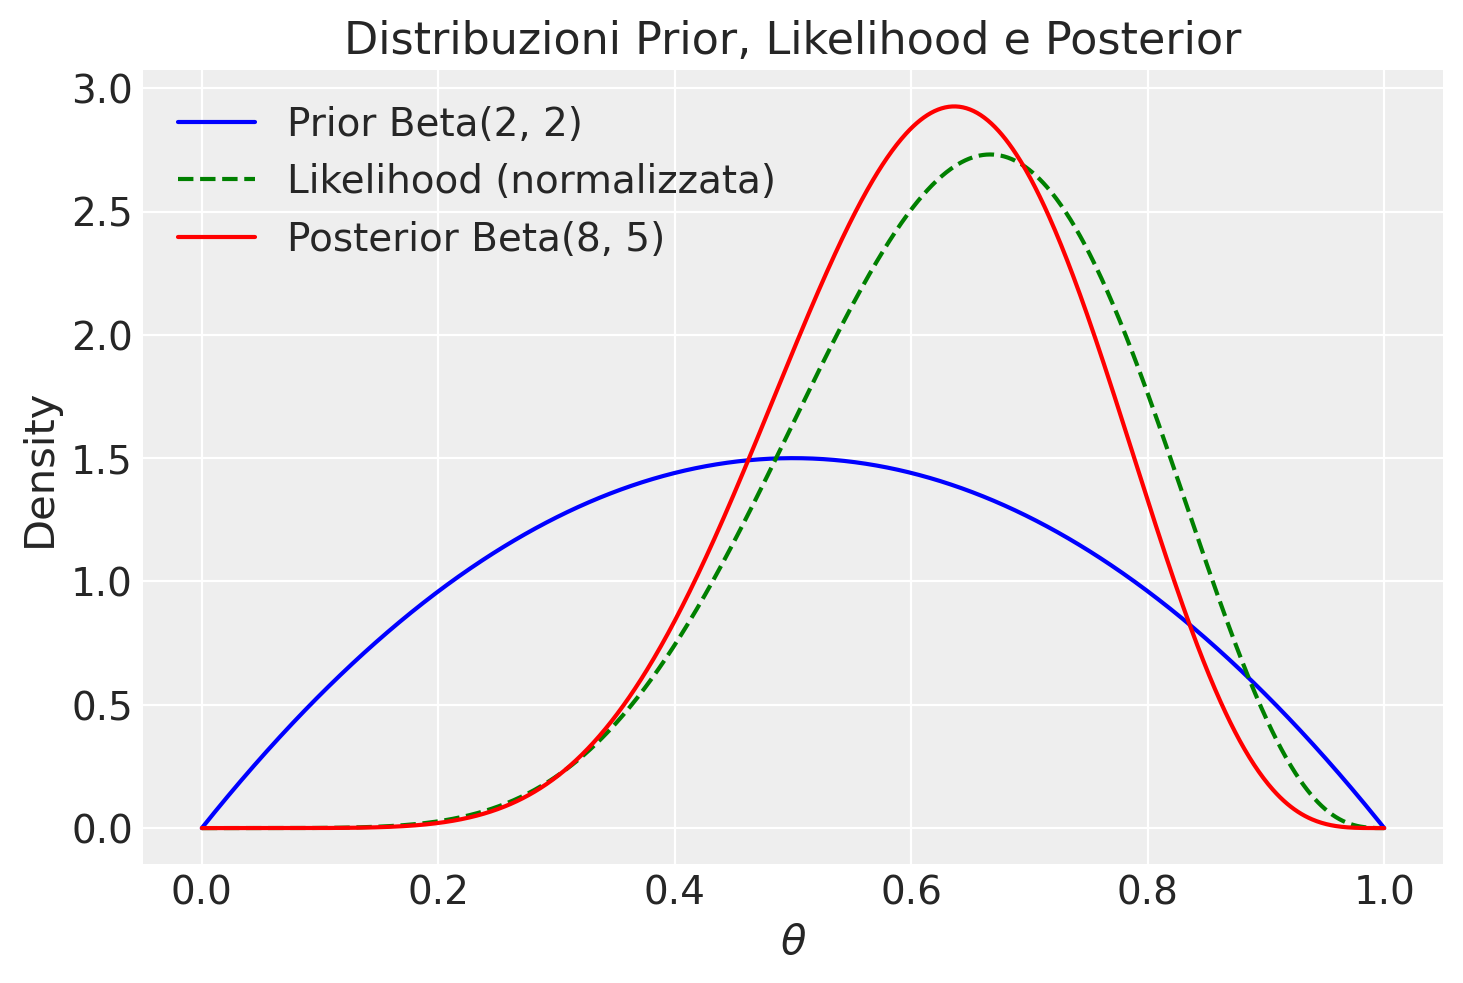

In [3]:
# Definiamo i parametri
alpha_prior, beta_prior = 2, 2
y, n = 6, 9
alpha_post, beta_post = alpha_prior + y, beta_prior + n - y

# Creiamo un array di valori theta
theta = np.linspace(0, 1, 1000)  # Aumentiamo la risoluzione per un calcolo più preciso

# Calcoliamo le PDF
prior_pdf = stats.beta.pdf(theta, alpha_prior, beta_prior)
likelihood = theta**y * (1-theta)**(n-y)

# Normalizziamo la verosimiglianza
likelihood_integral = trapz(likelihood, theta)
normalized_likelihood = likelihood / likelihood_integral

posterior_pdf = stats.beta.pdf(theta, alpha_post, beta_post)

# Disegnamo le distribuzioni
plt.plot(theta, prior_pdf, label=f'Prior Beta({alpha_prior}, {beta_prior})', color='blue')
plt.plot(theta, normalized_likelihood, label='Likelihood (normalizzata)', linestyle='--', color='green')
plt.plot(theta, posterior_pdf, label=f'Posterior Beta({alpha_post}, {beta_post})', color='red')

plt.xlabel('$\\theta$')
plt.ylabel('Density')
plt.title('Distribuzioni Prior, Likelihood e Posterior')
_ = plt.legend()

In questo codice, la funzione `trapz` viene usata per calcolare l'integrale della funzione di verosimiglianza non normalizzata su θ, fornendo il fattore di normalizzazione. Dividendo la funzione di verosimiglianza per questo fattore, otteniamo una funzione di verosimiglianza normalizzata, il cui integrale su [0, 1] è uguale a 1. La normalizzazione della verosimiglianza è eseguita solo a scopo di visualizzazione, per facilitare il confronto tra le curve. 

Pertanto, possiamo giungere a una conclusione soggettiva con un livello di probabilità del 94% che una proporzione di soggetti compresa tra il 40% e il 66% seguirà le istruzioni di un'autorità, nonostante queste istruzioni comportino evidenti danni ai propri compagni.

## Principali distribuzioni coniugate

Esistono altre combinazioni di verosimiglianza e distribuzione a priori che producono una distribuzione a posteriori con la stessa forma della distribuzione a priori. Ecco alcune delle più note coniugazioni tra modelli statistici e distribuzioni a priori:

- Nel modello Normale-Normale $\mathcal{N}(\mu, \sigma^2_0)$, la distribuzione a priori è $\mathcal{N}(\mu_0, \tau^2)$ e la distribuzione a posteriori è $\mathcal{N}\left(\frac{\mu_0\sigma^2 + \bar{y}n\tau^2}{\sigma^2 + n\tau^2}, \frac{\sigma^2\tau^2}{\sigma^2 + n\tau^2} \right)$.

- Nel modello Poisson-gamma $\text{Po}(\theta)$, la distribuzione a priori è $\Gamma(\lambda, \delta)$ e la distribuzione a posteriori è $\Gamma(\lambda + n \bar{y}, \delta +n)$.

- Nel modello esponenziale $\text{Exp}(\theta)$, la distribuzione a priori è $\Gamma(\lambda, \delta)$ e la distribuzione a posteriori è $\Gamma(\lambda + n, \delta +n\bar{y})$.

- Nel modello uniforme-Pareto $\text{U}(0, \theta)$, la distribuzione a priori è $\text{Pa}(\alpha, \varepsilon)$ e la distribuzione a posteriori è $\text{Pa}(\alpha + n, \max(y_{(n)}, \varepsilon))$.

## Conclusioni

In conclusione, l'utilizzo di priori coniugati presenta vantaggi e svantaggi. Cominciamo con i vantaggi principali. Il principale vantaggio dell'adozione di distribuzioni a priori coniugate risiede nella loro capacità di rendere l'analisi della distribuzione a posteriori trattabile da un punto di vista analitico. Ad esempio, nel corso di questo capitolo abbiamo esaminato come sia possibile formulare la distribuzione a posteriori in seguito a un esperimento composto da una serie di prove di Bernoulli (con una verosimiglianza binomiale), utilizzando una distribuzione Beta sia per la prior che per il posteriore.

Tuttavia, è cruciale riconoscere che i modelli basati sul concetto di famiglie coniugate presentano delle limitazioni intrinseche. Le distribuzioni coniugate a priori sono disponibili solamente per distribuzioni di verosimiglianza di base e relativamente semplici. Per modelli complessi e più realistici, la ricerca di priori coniugati diventa spesso un compito estremamente arduo, limitando quindi la loro utilità. Inoltre, anche quando le distribuzioni a priori coniugate sono disponibili, un modello che ne fa uso potrebbe non essere sufficientemente flessibile per adattarsi alle nostre credenze iniziali. Ad esempio, un modello basato su una distribuzione normale è sempre unimodale e simmetrico rispetto alla media $\mu$. Tuttavia, se le nostre conoscenze iniziali non sono simmetriche o non seguono una distribuzione unimodale, la scelta di una distribuzione a priori normale potrebbe non risultare la più adeguata [@Johnson2022bayesrules].

## Informazioni sull'Ambiente di Sviluppo

In [4]:
%load_ext watermark
%watermark -n -u -v -iv -w -m

Last updated: Thu Mar 28 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.2

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

arviz     : 0.17.1
scipy     : 1.12.0
pandas    : 2.2.1
seaborn   : 0.13.2
matplotlib: 3.8.3
numpy     : 1.26.4

Watermark: 2.4.3

